# Customer Voice: Amazon Review Sentiment Analysis

## Objective
The objective of this project is to analyze Amazon customer reviews using Natural Language Processing (NLP) and VADER sentiment analysis.

Reviews will be classified as positive, negative, or neutral. Visualizations will help identify customer opinion patterns and explore how sentiment relates to star ratings.

## Tools and Libraries
- Python
- Pandas
- NLTK VADER
- Matplotlib
- Seaborn

## Key Questions
1. What proportion of reviews are positive, negative, or neutral?
2. How does predicted sentiment compare with star ratings?
3. Which words appear frequently in customer reviews?
4. How can the findings help businesses understand customer feedback?

## Dataset
The dataset will contain customer review text and, if available, star ratings. Findings will be based on the data actually analyzed.

## 1. Import Required Libraries

We will use Pandas to work with review data and visualization libraries to present our findings.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


## 2. Obtain the Dataset

We will use a publicly available Amazon customer review dataset containing review text and star ratings. We will inspect its structure before cleaning or analyzing the data.

In [20]:
import pandas as pd

url = "https://raw.githubusercontent.com/Arjun-Mota/amazon-product-reviews-sentiment-analysis/master/1429_1.csv"

df = pd.read_csv(url, low_memory=False)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully!
Dataset shape: (34660, 21)

Column names:
['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


## 3. Data Cleaning and Preparation

In this section, we will identify the columns containing customer reviews and star ratings, remove unusable records, and prepare the text for sentiment analysis.

In [21]:
print(df.columns.tolist())

['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


In [22]:
# Find likely review-text and rating columns
text_candidates = [
    "reviews.text", "reviewText", "review_text",
    "text", "content"
]

rating_candidates = [
    "reviews.rating", "overall", "rating", "score"
]

text_col = next(
    (col for col in text_candidates if col in df.columns),
    None
)

rating_col = next(
    (col for col in rating_candidates if col in df.columns),
    None
)

print("Review text column:", text_col)
print("Rating column:", rating_col)

if text_col is None:
    print("Review text column not detected. Check the printed column names.")

Review text column: reviews.text
Rating column: reviews.rating


In [23]:
if text_col is None:
    raise ValueError("Review text column not found. Check Cell 9.")

reviews = df.copy()

reviews = reviews.dropna(subset=[text_col])
reviews[text_col] = reviews[text_col].astype(str).str.strip()

reviews = reviews[reviews[text_col] != ""]

if rating_col is not None:
    reviews[rating_col] = pd.to_numeric(
        reviews[rating_col], errors="coerce"
    )

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(reviews))
print("Missing review texts:", reviews[text_col].isna().sum())

display(reviews[[text_col] + ([rating_col] if rating_col else [])].head())

Rows before cleaning: 34660
Rows after cleaning: 34659
Missing review texts: 0


,reviews.text,reviews.rating
0,This product so far has not disappointed. My c...,5.0
1,great for beginner or experienced person. Boug...,5.0
2,Inexpensive tablet for him to use and learn on...,5.0
3,I've had my Fire HD 8 two weeks now and I love...,4.0
4,I bought this for my grand daughter when she c...,5.0


## 4. Sentiment Analysis Using VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon-based sentiment analysis tool. It calculates sentiment scores from text and is designed to work well with many forms of informal language.

We will use its compound score to classify each review as positive, negative, or neutral.

In [24]:
!pip -q install nltk

import nltk
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [25]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        label = "Positive"
    elif score <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"

    return pd.Series([score, label])

reviews[["compound_score", "sentiment"]] = reviews[text_col].apply(
    get_sentiment
)

print("Sentiment analysis completed!")
display(reviews[[text_col, "compound_score", "sentiment"]].head(10))

Sentiment analysis completed!


,reviews.text,compound_score,sentiment
0,This product so far has not disappointed. My c...,0.9194,Positive
1,great for beginner or experienced person. Boug...,0.8934,Positive
2,Inexpensive tablet for him to use and learn on...,0.4404,Positive
3,I've had my Fire HD 8 two weeks now and I love...,0.9884,Positive
4,I bought this for my grand daughter when she c...,0.7876,Positive
5,This amazon fire 8 inch tablet is the perfect ...,0.7096,Positive
6,"Great for e-reading on the go, nice and light ...",0.8885,Positive
7,"I gave this as a Christmas gift to my inlaws, ...",0.9273,Positive
8,Great as a device to read books. I like that i...,0.7809,Positive
9,I love ordering books and reading them with th...,0.6369,Positive


In [26]:
sentiment_counts = reviews["sentiment"].value_counts()

print("Sentiment counts:")
print(sentiment_counts)

print("\nSentiment percentages:")
print((sentiment_counts / len(reviews) * 100).round(2))

Sentiment counts:
sentiment
Positive    31031
Negative     2087
Neutral      1541
Name: count, dtype: int64

Sentiment percentages:
sentiment
Positive    89.53
Negative     6.02
Neutral      4.45
Name: count, dtype: float64


## 5. Visualizing Sentiment Distribution

Visualizations make the results easier to understand. We will first examine how many customer reviews are classified as positive, negative, and neutral.

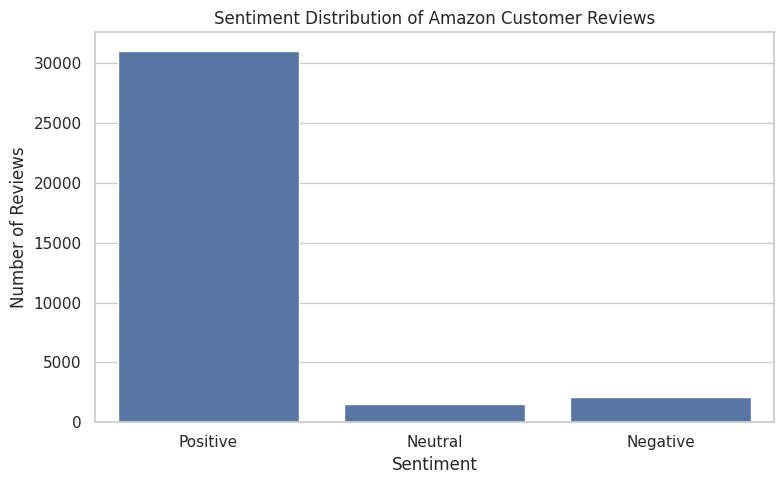

In [27]:
plt.figure(figsize=(8,5))

order = ["Positive","Neutral","Negative"]
sns.countplot(data=reviews, x="sentiment", order=order)

plt.title("Sentiment Distribution of Amazon Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.savefig("01_sentiment_distribution.png", dpi=300)
plt.show()

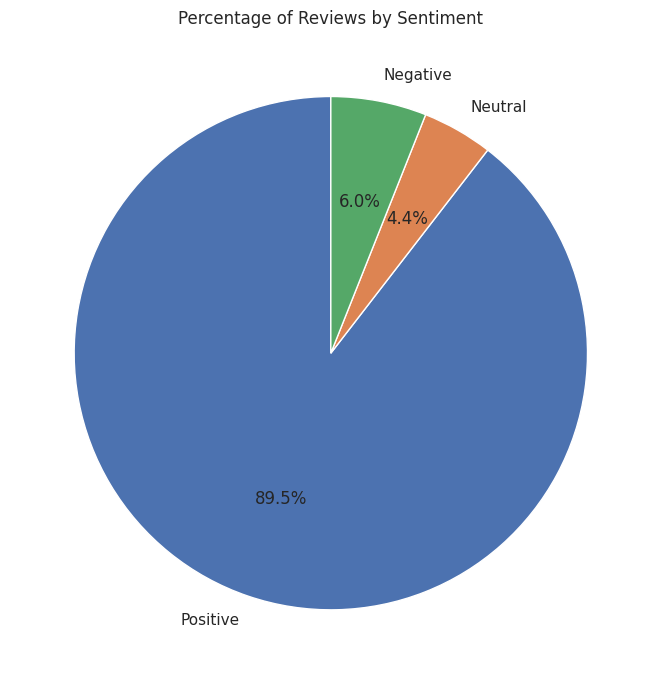

,Percentage
sentiment,
Positive,89.53
Neutral,4.45
Negative,6.02


In [28]:
sentiment_percent = (
    reviews["sentiment"]
    .value_counts(normalize=True)
    .reindex(["Positive", "Neutral", "Negative"], fill_value=0)
    * 100
)

plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_percent,
    labels=sentiment_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Reviews by Sentiment")
plt.tight_layout()
plt.savefig("02_sentiment_percentages.png", dpi=300)
plt.show()

display(sentiment_percent.round(2).rename("Percentage").to_frame())

## 6. Comparing Sentiment with Star Ratings

Customer ratings provide a useful comparison for the sentiment labels predicted by VADER. However, a star rating and the sentiment expressed in review text may not always agree.

Rating values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


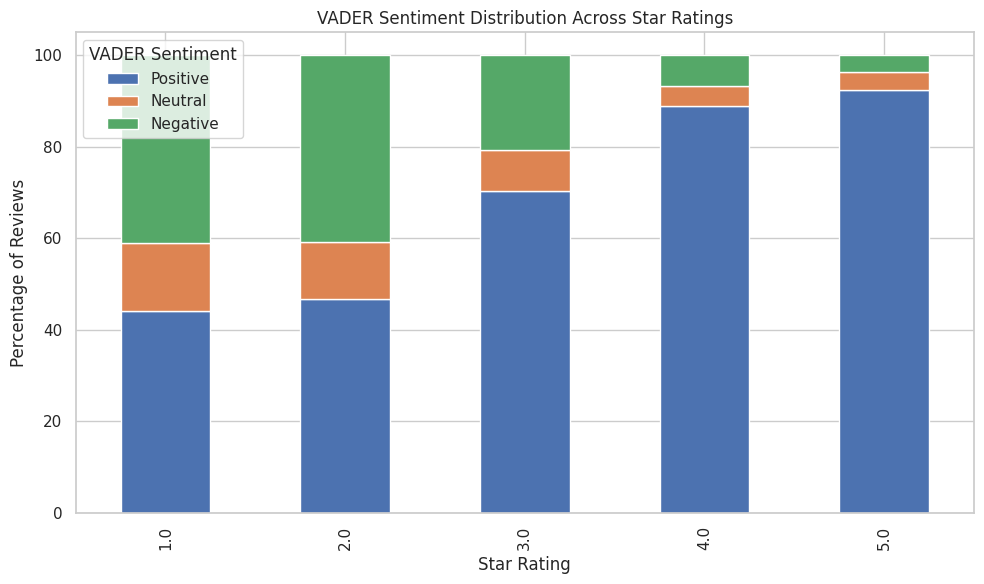

sentiment,Positive,Neutral,Negative
reviews.rating,,,
1.0,44.15,14.88,40.98
2.0,46.77,12.44,40.80
3.0,70.25,9.14,20.61
4.0,88.99,4.25,6.76
5.0,92.45,3.91,3.64


In [29]:
if rating_col is not None:
    rating_data = reviews.dropna(subset=[rating_col]).copy()

    print("Rating values:")
    print(sorted(rating_data[rating_col].unique()))

    rating_sentiment = pd.crosstab(
        rating_data[rating_col],
        rating_data["sentiment"],
        normalize="index"
    ) * 100

    rating_sentiment = rating_sentiment.reindex(
        columns=["Positive", "Neutral", "Negative"],
        fill_value=0
    )

    rating_sentiment.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )

    plt.title("VADER Sentiment Distribution Across Star Ratings")
    plt.xlabel("Star Rating")
    plt.ylabel("Percentage of Reviews")
    plt.legend(title="VADER Sentiment")
    plt.tight_layout()
    plt.savefig("03_sentiment_vs_ratings.png", dpi=300)
    plt.show()

    display(rating_sentiment.round(2))
else:
    print("No rating column detected. Skipping rating comparison.")

Average VADER compound score by star rating:


,Average Compound Score
reviews.rating,
1.0,0.025
2.0,0.068
3.0,0.340
4.0,0.596
5.0,0.673


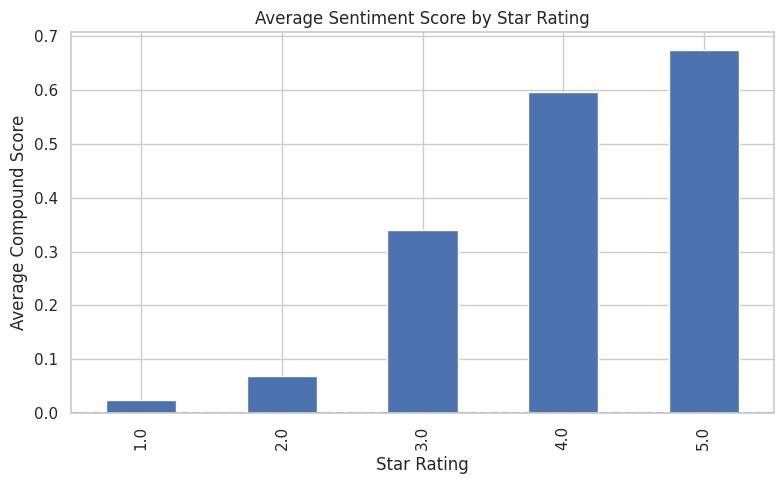

In [30]:
if rating_col is not None:
    average_scores = (
        reviews.dropna(subset=[rating_col])
        .groupby(rating_col)["compound_score"]
        .mean()
    )

    print("Average VADER compound score by star rating:")
    display(average_scores.round(3).to_frame("Average Compound Score"))

    average_scores.plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.axhline(0, linestyle="--")
    plt.title("Average Sentiment Score by Star Rating")
    plt.xlabel("Star Rating")
    plt.ylabel("Average Compound Score")
    plt.tight_layout()
    plt.savefig("04_average_sentiment_by_rating.png", dpi=300)
    plt.show()

## 7. Interpreting the Results

The charts help us understand the overall sentiment of customer reviews and explore whether the language used in reviews is consistent with star ratings. We will base the final conclusions on the observed results rather than assuming that most reviews are positive or negative.


## 8. Frequently Used Words in Customer Reviews

Examining frequent words helps us understand which terms appear repeatedly in customer feedback. We will remove common English stop words so that the chart focuses on more meaningful words.

In [31]:
!pip -q install wordcloud

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
import re

# Combine review text into one string
all_text = " ".join(reviews[text_col].astype(str).tolist()).lower()

# Extract words and remove common stop words
words = re.findall(r"\b[a-z]{3,}\b", all_text)

stop_words = set(ENGLISH_STOP_WORDS)
custom_stop_words = {
    "product", "amazon", "use", "used", "using",
    "one", "would", "also", "get", "got", "buy",
    "bought", "item", "really"
}
stop_words.update(custom_stop_words)

filtered_words = [
    word for word in words
    if word not in stop_words
]

word_counts = Counter(filtered_words)

print("Total words after filtering:", len(filtered_words))
print("\nTop 20 most frequent words:")
display(pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
))

Total words after filtering: 430379

Top 20 most frequent words:


,Word,Frequency
0,great,11873
1,tablet,9089
2,love,6645
3,easy,6223
4,kindle,5414
5,good,5092
6,price,4200
7,like,3840
8,works,3115
9,just,3082


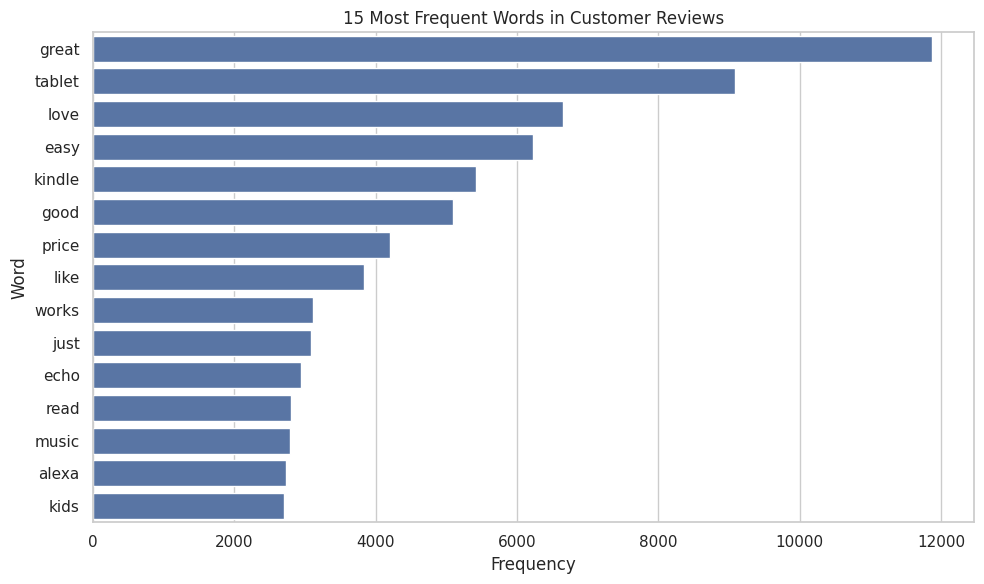

In [32]:
top_words = word_counts.most_common(15)

word_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

plt.figure(figsize=(10, 6))
sns.barplot(data=word_df, x="Frequency", y="Word")

plt.title("15 Most Frequent Words in Customer Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()

plt.savefig("05_most_frequent_words.png", dpi=300)
plt.show()

In [33]:
def get_top_words(sentiment_label, n=10):
    text = " ".join(
        reviews.loc[reviews["sentiment"] == sentiment_label, text_col]
        .astype(str)
    ).lower()

    tokens = re.findall(r"\b[a-z]{3,}\b", text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return Counter(tokens).most_common(n)


positive_words = get_top_words("Positive")
negative_words = get_top_words("Negative")

comparison = pd.DataFrame({
    "Positive Review Words": pd.Series(dict(positive_words)),
    "Negative Review Words": pd.Series(dict(negative_words))
}).fillna(0).astype(int)

print("Frequent words in positive reviews:")
display(pd.DataFrame(positive_words, columns=["Word", "Frequency"]))

print("Frequent words in negative reviews:")
display(pd.DataFrame(negative_words, columns=["Word", "Frequency"]))

Frequent words in positive reviews:


,Word,Frequency
0,great,11624
1,tablet,8283
2,love,6540
3,easy,6097
4,good,4815
5,kindle,4802
6,price,3885
7,like,3559
8,works,2857
9,echo,2773


Frequent words in negative reviews:


,Word,Frequency
0,tablet,584
1,kindle,441
2,like,246
3,just,225
4,good,222
5,price,213
6,don,201
7,apps,199
8,stick,198
9,great,197


## 9. Key Findings and Business Insights

In this section, we will summarize the observed sentiment distribution and connect the findings to possible business decisions. All conclusions must be based on the actual dataset results.


In [34]:
total_reviews = len(reviews)
sentiment_counts = reviews["sentiment"].value_counts()
sentiment_percentages = (
    reviews["sentiment"].value_counts(normalize=True) * 100
)

print("KEY FINDINGS")
print("=" * 40)
print("Total reviews analyzed:", total_reviews)

for label in ["Positive", "Neutral", "Negative"]:
    count = int(sentiment_counts.get(label, 0))
    percentage = sentiment_percentages.get(label, 0)
    print(f"{label}: {count} reviews ({percentage:.2f}%)")

dominant_sentiment = sentiment_counts.idxmax()
print("\nMost common predicted sentiment:", dominant_sentiment)

print("\nBUSINESS INTERPRETATION")
if dominant_sentiment == "Positive":
    print(
        "Positive sentiment is the most common. Businesses could examine "
        "positive reviews to identify product strengths worth maintaining "
        "and highlighting in marketing."
    )
elif dominant_sentiment == "Negative":
    print(
        "Negative sentiment is the most common. Businesses should examine "
        "negative reviews to identify recurring complaints and areas for improvement."
    )
else:
    print(
        "Neutral sentiment is the most common. Businesses could investigate "
        "whether reviews contain factual descriptions, mixed opinions, "
        "or language that VADER finds difficult to classify."
    )

print(
    "\nNote: VADER predicts sentiment from text. These results do not "
    "necessarily represent every customer's true opinion."
)

KEY FINDINGS
Total reviews analyzed: 34659
Positive: 31031 reviews (89.53%)
Neutral: 1541 reviews (4.45%)
Negative: 2087 reviews (6.02%)

Most common predicted sentiment: Positive

BUSINESS INTERPRETATION
Positive sentiment is the most common. Businesses could examine positive reviews to identify product strengths worth maintaining and highlighting in marketing.

Note: VADER predicts sentiment from text. These results do not necessarily represent every customer's true opinion.


## 10. Limitations

- VADER relies on a sentiment lexicon and rules, so it may misinterpret sarcasm, context, or product-specific expressions.
- Sentiment predictions are not guaranteed to match customer star ratings.
- Frequently used words do not always reveal the reason behind a customer's opinion.
- Results describe the dataset analyzed and may not represent all Amazon customers.
- Business recommendations should be checked against the actual review text before decisions are made.